In [2]:
import sys

sys.path.append("..")
sys.path.append("../..")


from hydra import initialize, compose
import numpy as np
from hydra.utils import instantiate
import matplotlib.pyplot as plt

import networkx as nx

from statsmodels.tsa.api import VAR
import matplotlib
from scipy import stats

from graphic_tools import rename_labels, colors


In [3]:
%load_ext autoreload
%autoreload 2

# $V_{conf,l}$

break!
  Resampling section 0 (attempt 2)
break!
  Resampling section 0 (attempt 2)
break!
  Resampling section 0 (attempt 2)
break!
  Resampling section 0 (attempt 2)


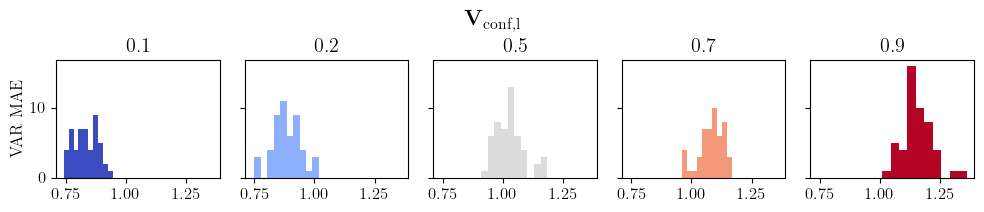

In [23]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)
# To keep everything clean we use hydra for HPs.
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")

cfg.generator.remove_n_variables_for_confounding = 1

res = {}

for n, y in enumerate([0.1, 0.2, 0.5, 0.7, 0.9]):
    cfg.n_vars = 5 + 1
    cfg.generator.lagged.alternativ_parameter_range = [0.8, 0.9]
    cfg.generator.lagged.alternative_link_proba = y
    cfg.generator.lagged.alternative_coeff_ts = 1
    generator = instantiate(cfg.generator)
    stack = []
    stack2 = []
    for step in range(50):
        X, Y, _, _, _, _, _, _, _ = generator.get_sample()
        a = np.abs(VAR(X.T).fit(maxlags=3).resid).mean()
        stack.append(a)
    axs[n].hist(stack, color=colors[n])
    axs[n].set_title(f"{y}")

axs[0].set_ylabel("VAR MAE")
plt.tight_layout()
fig.suptitle(rename_labels["lagged_confounder"], fontsize=16, y=1.05)
plt.savefig("../img/lagged_conf.pdf", bbox_inches="tight", dpi=500)

# $V_{conf,i}$

(2, 250)
(2, 250)
(2, 250)
(2, 250)
(2, 250)


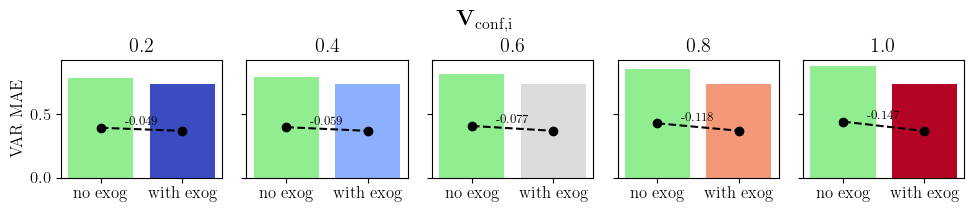

In [5]:
random_ts = np.random.uniform(size=(1, 10000))
# To keep everything clean we use hydra for HPs.
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
    

fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)

for n, it in enumerate([0.2, 0.4, 0.6, 0.8, 1.0]):
    cfg.generator.exog.link_proba = it
    generator = instantiate(cfg.generator)
    X, Y, _, exog, exog_ts, _, _, _, _ = generator.get_sample()
    a = np.abs(VAR(X.T, exog=exog_ts.T).fit(maxlags=3).resid).mean()
    b = np.abs(
        VAR(
            X.T,
        )
        .fit(maxlags=3)
        .resid
    ).mean()
    axs[n].bar(["no exog", "with exog"], [b, a], color=["lightgreen", colors[n]])
    # Draw a line showing the difference between the two bars
    axs[n].plot([0, 1], [b / 2, a / 2], color="black", linestyle="--", marker="o")
    # Annotate the difference above the line
    diff = a - b
    axs[n].annotate(
        f"{diff:.3f}",
        xy=(0.5, max(a, b)),
        xytext=(0.5, max(a / 2, b / 2) + 0.02),
        ha="center",
        fontsize=9,
        color="black",
    )
    axs[n].set_title(f"{it}")

axs[0].set_ylabel("VAR MAE")
plt.tight_layout()
fig.suptitle(rename_labels["instant_confounder"], fontsize=16, y=1.05)
plt.savefig("../img/inst_conf.pdf", bbox_inches="tight", dpi=500)
# SOmehow this could be better as the exog_effect alone does not imply confounding.

# $V_{faith,l}$

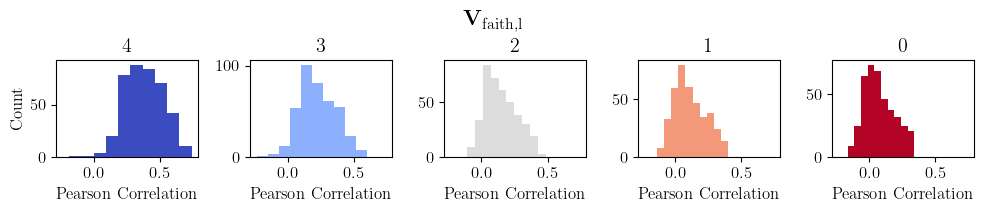

In [4]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True)
# To keep everything clean we use hydra for HPs.
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
    
cfg.generator.lagged.link_proba = 0.0

for n, y in enumerate(["4", "3", "2", "1", "0"]):
    generator = instantiate(cfg.generator)
    stack = []
    for x in range(100):
        mask = np.load("../masks/masks_5_4_faith_lagged_" + y + "/" + str(x) + ".npy")
        X, Y, Y0, _, _, _, _, _, _ = generator.get_sample(link_mask=mask)

        direct_links = np.where(Y[0] < 0)
        for x in range(len(direct_links[0])):
            # We have multiple direct links, so we take the first one
            pnr = stats.pearsonr(
                X[direct_links[0][x]], np.roll(X[direct_links[1][x]], 2)
            ).statistic
            stack.append(pnr)

    axs[n].hist(stack, color=colors[n], bins=10, density=False)
    axs[n].set_title(f"{y}")
    axs[n].set_xlabel("Pearson Correlation")
axs[0].set_ylabel("Count")
plt.tight_layout()
fig.suptitle(rename_labels["faith_lagged"], fontsize=16, y=1.05)
plt.savefig("../img/faith_l.pdf", bbox_inches="tight", dpi=500)

# $V_{faith,i}$

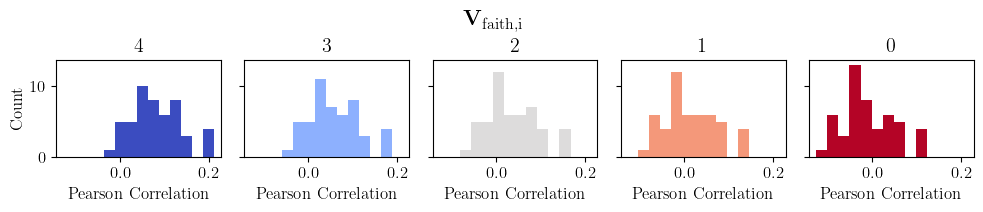

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)
# To keep everything clean we use hydra for HPs.
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
cfg.generator.instant.link_proba = 0.0
cfg.generator.lagged.link_proba = 0.0

for n, y in enumerate(["4", "3", "2", "1", "0"]):
    generator = instantiate(cfg.generator)
    stack = []
    for x in range(50):
        mask = np.load("../masks/masks_5_faith_instant_" + y + "/" + str(x) + ".npy")
        X, Y, Y0, _, _, _, _, _, _ = generator.get_sample(instant_link_mask=mask)
        G = nx.DiGraph()
        n_vars = Y0[0].shape[0]
        for i in range(n_vars):
            for j in range(n_vars):
                if Y0[0][i, j] != 0:
                    G.add_edge(j, i)  # cause -> effect
        topo_order = list(nx.topological_sort(G))
        stack.append(stats.pearsonr(X[topo_order[0]], X[topo_order[-1]]).statistic)
    axs[n].hist(stack, color=colors[n], bins=10, density=False)
    axs[n].set_title(f"{y}")
    axs[n].set_xlabel("Pearson Correlation")

axs[0].set_ylabel("Count")
plt.tight_layout()
fig.suptitle(rename_labels["faith_inst"], fontsize=16, y=1.05)
plt.savefig("../img/faith_i.pdf", bbox_inches="tight", dpi=500)

# $V_{faith,z}$

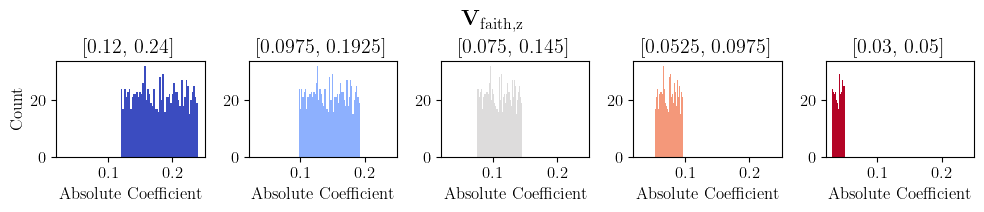

In [4]:
# define levels first so we can size the axes array accordingly
levels = [
    [0.12,0.24],
    [0.0975,0.1925],
    [0.075,0.145],
    [0.0525,0.0975],
    [0.03,0.05],
]

fig, axs = plt.subplots(1, len(levels), figsize=(10, 2), sharex=True)
# To keep everything clean we use hydra for HPs.
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")


for n, level in enumerate(levels):

    cfg.generator.lagged.param_range = level
    cfg.generator.instant.param_range = level
    generator = instantiate(cfg.generator)
    stack = []
    for x in range(100):
        X, Y, Y0, _, _, _, _, _, _ = generator.get_sample()
        arr = np.concatenate([np.abs(Y).ravel(), np.abs(Y0).ravel()])
        arr = arr[arr != 0]
        # extend stack with scalar values so stack stays a flat list
        stack.extend(arr)
        # plot the collected non-zero coefficients
    axs[n].hist(stack, color=colors[n % len(colors)], bins=50, density=False)
    axs[n].set_title(f"{level}")
    axs[n].set_xlabel("Absolute Coefficient")
axs[0].set_ylabel("Count")
plt.tight_layout()
fig.suptitle(rename_labels["faith_zero"], fontsize=16, y=1.05)
plt.savefig("../img/faith_z.pdf", bbox_inches="tight", dpi=500)

# $V_{empty}$

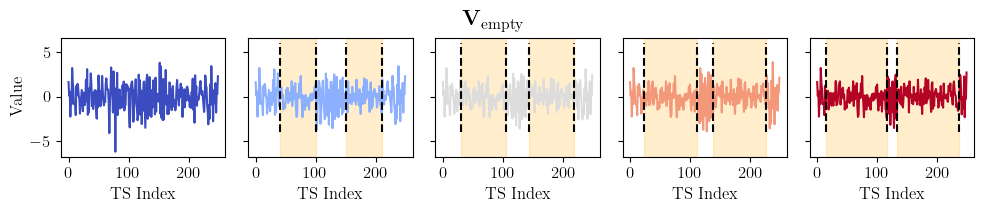

In [25]:
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
cfg.nonstationary_change = 0
cfg.generator.nonstationary = True
cfg.generator.drop_struc_for_window = True

fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)
for n, it in enumerate(
    [
    [],
    [40, 100, 150, 210],
    [31, 106, 144, 219],
    [23, 111, 139, 227],
    [14, 117, 133, 236],
    ]
):
    generator = instantiate(
        cfg.generator,
        change_points=it,
    )
    X, Y, _, _, _, _, _, _, _  = generator.get_sample()
    axs[n].plot(X.T[:, 0], color=colors[n])
    axs[n].vlines(it, -4, 6, colors="black", linestyles="dashed")
    # Draw rectangles between every second pair of vlines
    for i in range(0, len(it) - 1, 2):
        axs[n].axvspan(it[i], it[i + 1], ymin=0, ymax=1, color="orange", alpha=0.2)
    axs[n].set_xlabel("TS Index")
axs[0].set_ylabel("Value")
plt.tight_layout()
fig.suptitle(rename_labels["missing_info"], fontsize=16, y=1.05)
plt.savefig("../img/missing_structure.pdf", bbox_inches="tight", dpi=500)

# $V_{length}$

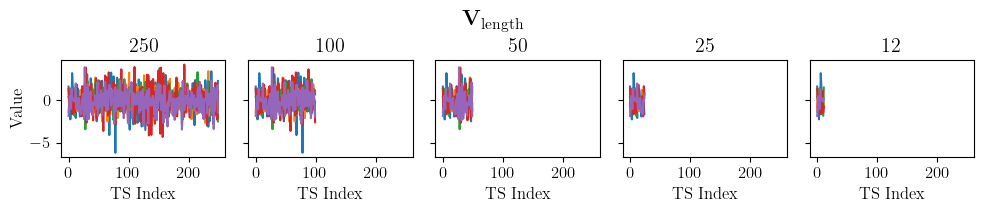

In [28]:
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)

for n, y in enumerate([250, 100, 50, 25, 12]):
    generator = instantiate(cfg.generator, time_series_n=y)
    X, Y, _, _, _, _, _, _, _ = generator.get_sample()

    _ = axs[n].plot(X.T)
    axs[n].set_title(f"{y}")
    axs[n].set_xlabel("TS Index")

axs[0].set_ylabel("Value")
plt.tight_layout()
fig.suptitle(rename_labels["length"], fontsize=16, y=1.05)

plt.savefig("../img/ts_length.pdf", bbox_inches="tight", dpi=500)

# $V_{mcar,mar,mnar}$

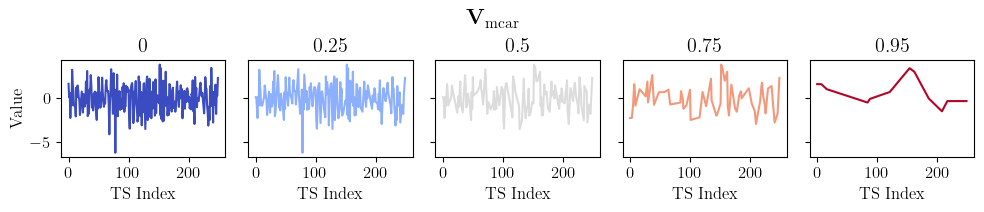

In [14]:
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)

for n, y in enumerate([0, 0.25, 0.5, 0.75, 0.95]):
    generator = instantiate(cfg.generator, interpolate=y , missingness_type="MCAR")
    X, Y, _, _, _, _, _, _,_ = generator.get_sample()

    _ = axs[n].plot(np.arange(X.T.shape[0]), X.T[:, 0], color=colors[n])
    axs[n].set_title(f"{y}")
    axs[n].set_xlabel("TS Index")

axs[0].set_ylabel("Value")
plt.tight_layout()
fig.suptitle(rename_labels["mcar"], fontsize=16, y=1.05)
plt.savefig("../img/mcar.pdf", bbox_inches="tight", dpi=500)

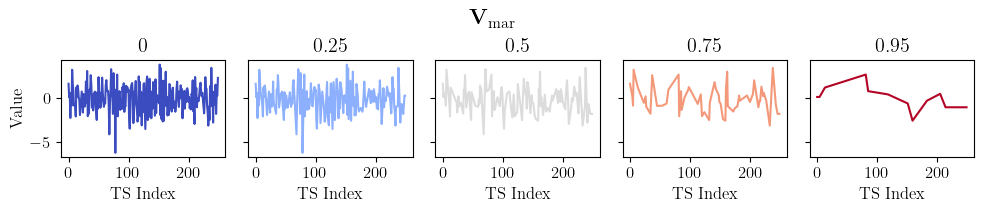

In [5]:
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)

for n, y in enumerate([0, 0.25, 0.5, 0.75, 0.95]):
    generator = instantiate(cfg.generator, interpolate=y , missingness_type="MAR",missingness_base_path="../semi_synthetic_bases/rivers_ts_flood.csv")
    X, Y, _, _, _, _, _, _,_ = generator.get_sample()

    _ = axs[n].plot(np.arange(X.T.shape[0]), X.T[:, 0], color=colors[n])
    axs[n].set_title(f"{y}")
    axs[n].set_xlabel("TS Index")

axs[0].set_ylabel("Value")
plt.tight_layout()
fig.suptitle(rename_labels["mar"], fontsize=16, y=1.05)
plt.savefig("../img/mar.pdf", bbox_inches="tight", dpi=500)

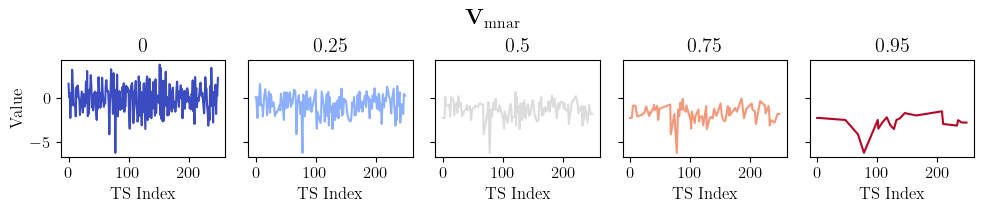

In [6]:
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)

for n, y in enumerate([0, 0.25, 0.5, 0.75, 0.95]):
    generator = instantiate(cfg.generator, interpolate=y , missingness_type="MNAR",missingness_base_path="../semi_synthetic_bases/rivers_ts_flood.csv")
    X, Y, _, _, _, _, _, _,_ = generator.get_sample()

    _ = axs[n].plot(np.arange(X.T.shape[0]), X.T[:, 0], color=colors[n])
    axs[n].set_title(f"{y}")
    axs[n].set_xlabel("TS Index")

axs[0].set_ylabel("Value")
plt.tight_layout()
fig.suptitle(rename_labels["mnar"], fontsize=16, y=1.05)
plt.savefig("../img/mnar.pdf", bbox_inches="tight", dpi=500)

# $V_{Scale}$

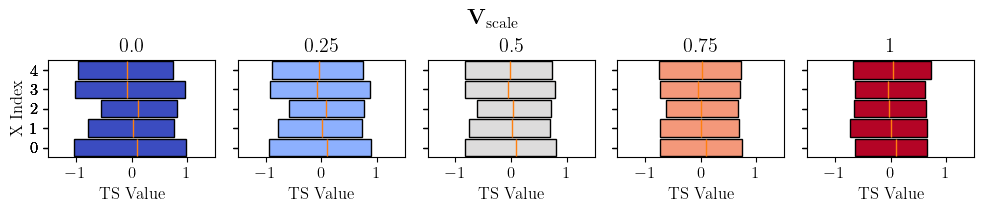

In [ ]:
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)

for n, y in enumerate([0.0, 0.25, 0.5, 0.75, 1]):
    generator = instantiate(
        cfg.generator, normalize="standardization", standardization_factor=y
    )
    X, Y, _, _, _, _, _, _, _ = generator.get_sample()
    axs[n].set_title(f"{y}")
    axs[n].boxplot(
        X.T,
        positions=np.arange(X.shape[0]),
        vert=False,
        widths=0.9,
        patch_artist=True,
        boxprops=dict(facecolor=colors[n]),
    )
    axs[n].set_xlabel("TS Value")
    axs[n].set_xlim([-1.5, 1.5])

    # Remove whiskers from the boxplot
    for line in axs[n].lines:
        line.set_visible(False)
    # Redraw only the boxes and median
    for box in axs[n].artists:
        box.set_edgecolor("black")
    for median in axs[n].lines[4::6]:
        median.set_visible(True)
axs[0].set_ylabel("X Index")
plt.tight_layout()

fig.suptitle(rename_labels["standardization"], fontsize=16, y=1.05)

plt.savefig("../img/standardization_mixture.pdf", bbox_inches="tight", dpi=500)

## $V_{coef}$

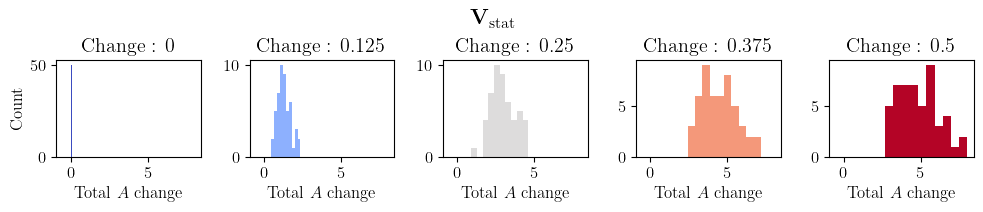

In [45]:
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=False)

for n, it in enumerate([0, 0.125,0.25,0.375, 0.5]):
    cfg.generator.change_points = [50, 100, 150, 200]
    cfg.generator.nonstationary = True
    cfg.nonstationary_change = it
    generator = instantiate(cfg.generator)
    stack = []
    for x in range(50):
        X, Y, Y0, _, _, _, _, _,_ = generator.get_sample()
        stack.append(np.abs(Y[0] - Y[-1]).sum())
    _ = axs[n].hist(stack, color=colors[n])
    # axs[n].vlines(cp, -4, 6, colors="black", linestyles="dashed")
    axs[n].set_title("Change : " + str(it))
    axs[n].set_xlabel("Total $A$ change")

axs[0].set_ylabel("Count")
plt.tight_layout()

fig.suptitle(
    rename_labels["nonstat_n"],
    fontsize=16,
    y=1.05,
)

plt.savefig("../img/coef.pdf", bbox_inches="tight", dpi=500)

## $V_{stat}$

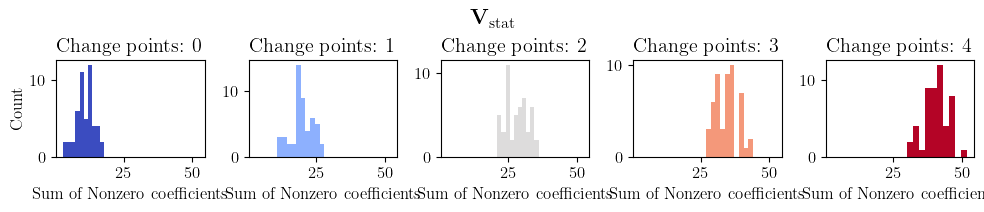

In [7]:
with initialize(version_base=None, config_path="../../config/"):
    cfg = compose(config_name="generate_dataset.yaml")
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=False)

change_points = [
    [],
    [125],
    [83, 166],
    [63, 126, 187],
    [50, 100, 150, 200],
]

for n, it in enumerate(change_points):
    cfg.generator.change_points = it
    cfg.generator.nonstationary = False
    generator = instantiate(cfg.generator)
    stack = []
    for x in range(50):
        X, Y, Y0, _, _, _, _, _,_ = generator.get_sample()
                
        stack.append(np.sum(Y.sum(axis=0) != 0))
    _ = axs[n].hist(stack, color=colors[n])
    # axs[n].vlines(cp, -4, 6, colors="black", linestyles="dashed")
    axs[n].set_title("Change points: " + str(len(it)))
    axs[n].set_xlabel("Sum of Nonzero coefficients")

axs[0].set_ylabel("Count")
plt.tight_layout()

fig.suptitle(
    rename_labels["nonstat_n"],
    fontsize=16,
    y=1.05,
)

plt.savefig("../img/nonstat.pdf", bbox_inches="tight", dpi=500)